# 06 SLC Coherence Preprocessing

**Author:** Florian Klaver  
In this notebook the downloaded raw SLC .SAFE files are preprocessed with SNAP and the coherence features are computed.

### Workflow

For each mowing event with a valid SLC **quadruplet**, this notebook computes two coherence rasters using ESA SNAP as a headless processing backend:

| Pair | Master | Slave | Output | Meaning |
|------|--------|-------|--------|---------|
| coherence_before | SLC_t1 (before_far) | SLC_t2 (before_near) | `<match_id>_coh_before.tif` | Both scenes before mowing -> low coherence (growing grass decorrelates) |
| coherence_after  | SLC_t3 (after, 1st) | SLC_t4 (after, 2nd) | `<match_id>_coh_after.tif` | Both scenes after mowing -> high coherence (stable stubble) |

**Quadruplet design (Tamm et al. 2016):** Contrasting to the S2 and S1 GRD images, which both use 3 images ot compute the necessary features, for coherence 4 images are necessary. Two images before the mowing event and two after. Coherence is then calculated between those two sets:  
- Coherence before mowing derived from t1 to t2 -> High grass, signal gets scattered -> low coherence expected
- Coherence after mowing derived from t3 to t4 -> Low grass, signal more stable -> high coherence expected


### SNAP processing chain (per pair)

```
Read (master) ──► TOPSAR-Split ──► Apply-Orbit-File ──┐
                                                       ├──► Back-Geocoding ──► Coherence ──► TOPSAR-Deburst ──► Terrain-Correction ──► Write
Read (slave)  ──► TOPSAR-Split ──► Apply-Orbit-File ──┘
```

- **TOPSAR-Split**: selects the relevant IW subswath and bursts covering the study area
- **Apply-Orbit-File**: downloads precise orbit vectors (POEORB)
- **Back-Geocoding**: coregisters slave to master geometry using SRTM DEM
- **Coherence**: estimates complex coherence (window: 10 range × 3 azimuth ≈ 20×20 m)
- **TOPSAR-Deburst**: merges burst boundaries
- **Terrain-Correction**: geocodes to EPSG:2056, 20 m pixel spacing
- **Write**: GeoTIFF with 2 bands: VV coherence [0,1], VH coherence [0,1]

### Pilot mode

When `PILOT_MODE = True` **only the first available event** is processed to test and verify the full pipeline before launching the computationally expensive batch run.

---
## 0. Scan & Clean Existing Coherence TIFs and .SAFE zip-files

This diagonsis/bugfixing cell was used to identify and remove corrupted .tif files after certain pre-processing runs of this notebook. So this cell was added after the first few rund of the rest, after finding issues in some processed files. It was then run to identify which of these files were affected and needed to be removed before rerunning the rest of the improved notebook again.

In [3]:
import os, glob
import rasterio
import numpy as np

_COH_DIR = r'..\data\features_coherence'
_broken = []   # list of (path, reason)
_ok = []

# Scan all coherence TIFs in the coherence directory
for _tif in sorted(glob.glob(os.path.join(_COH_DIR, '*.tif'))):
    try:
        with rasterio.open(_tif) as _src:
            if _src.count < 2:
                _broken.append((_tif, f'only {_src.count} band(s)'))
                continue
            _arr = _src.read(2).astype(np.float32)
            if np.any(np.isnan(_arr)):
                _broken.append((_tif, f'band 2 contains NaN'))
            elif np.all(_arr == 0):
                _broken.append((_tif, 'band 2 all-zero (silent SNAP failure)'))
            else:
                _ok.append(os.path.basename(_tif))
    except Exception as _e:
        _broken.append((_tif, f'unreadable: {_e}'))

print(f'=== SCAN: {len(_ok)} OK,  {len(_broken)} BROKEN ===\n')
if _broken:
    print('BROKEN FILES: review before deleting:')
    for _p, _r in _broken:
        print(f'  {os.path.basename(_p):45s}  [{_r}]')
else:
    print('All TIF files are valid. Nothing to delete.')

# Remove broken files
# print('\nDeleting broken files...')
# for _p, _r in _broken:
#     os.remove(_p)
#     print(f'  Deleted: {os.path.basename(_p)}')


=== SCAN: 72 OK,  0 BROKEN ===

All TIF files are valid. Nothing to delete.


In [ ]:
# Debugging Cell to check if the original .SAFE.zip files are intact (not corrupted downloads)
import zipfile
SLC_DIR = r'..\data\Sentinel_S1_SLC'

slc_files = sorted(glob.glob(os.path.join(SLC_DIR, '*.SAFE.zip')))
print(f'Checking {len(slc_files)} .SAFE.zip files...\n')

for zpath in slc_files:
    fname = os.path.basename(zpath)
    size_gb = os.path.getsize(zpath) / 1e9
    try:
        with zipfile.ZipFile(zpath, 'r') as zf:
            bad = zf.testzip()   # returns name of first bad file, or None if all OK
        status = f'CORRUPT (first bad: {bad})' if bad else f'OK  ({size_gb:.2f} GB)'
    except zipfile.BadZipFile as e:
        status = f'BAD ZIP: {e}'
    except Exception as e:
        status = f'ERROR: {e}'
    print(f'  {fname}  ->  {status}')

---
## 1. Setup

In [7]:
import os
import glob
import configparser
import subprocess
import xml.etree.ElementTree as ET
from xml.dom import minidom
import importlib
from pyproj import Transformer
import rasterio as _rio
import shutil, time, zipfile as _zipfile


import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from pyproj import CRS

base_dir = Path(os.getcwd()).parent.resolve()

if str(base_dir) not in sys.path:
    sys.path.append(str(base_dir))

import src.config as cfg
importlib.reload(cfg)

# Pilot switch
PILOT_MODE = False

# Paths 
SLC_DIR = r'..\data\Sentinel_S1_SLC'
COH_DIR = r'..\data\features_coherence'
SLC_COVERAGE_PATH = r'..\data\slc_event_coverage.csv'
SLC_INDEX_PATH = r'..\data\slc_scene_index.csv'
S2_DIR = r'..\data\Sentinel_CH'
SNAP_TMPDIR = r'..\data\_snap_tmp'

os.makedirs(COH_DIR, exist_ok=True)
os.makedirs(SNAP_TMPDIR, exist_ok=True)

# SNAP configuration 
SNAP_HOME = r'C:\Program Files\esa-snap'
GPT = os.path.join(SNAP_HOME, 'bin', 'gpt.exe')

_pyrosar_cfg = os.path.join(os.path.expanduser('~'), '.pyrosar', 'config.ini')
if not os.path.exists(_pyrosar_cfg):
    os.makedirs(os.path.dirname(_pyrosar_cfg), exist_ok=True)
    _cfg = configparser.RawConfigParser()
    _cfg.add_section('SNAP')
    _cfg.set('SNAP', 'path', os.path.join(SNAP_HOME, 'bin', 'snap64.exe'))
    _cfg.set('SNAP', 'gpt',  GPT)
    _cfg.set('SNAP', 'etc',  os.path.join(SNAP_HOME, 'etc'))
    with open(_pyrosar_cfg, 'w') as f:
        _cfg.write(f)
    print(f'pyroSAR config written: {_pyrosar_cfg}')

# IW Subswath configuration (imported from config.py) 
# IW2 verified in SNAP Desktop: covers Zürich Airport on orbit 15 ascending.
# The subswath geometry is fixed for a given relative orbit: constant for all dates.
SUBSWATH = cfg.SUBSWATH
FIRST_BURST = cfg.FIRST_BURST
LAST_BURST = cfg.LAST_BURST

# Coherence processing parameters (imported from config.py) 
# Coherence estimation window, matched to Tamm et al. (2016) R80/R160 setup
# ENL ≈ 46, ground footprint ≈ 71m × 69m
COH_WINDOW_RG = cfg.COH_WIN_RG
COH_WINDOW_AZ = cfg.COH_WIN_AZ
OUTPUT_SPACING_M = cfg.OUTPUT_SPACING

# S2 reference for AOI bounds
s2_files = sorted(glob.glob(os.path.join(S2_DIR, '*.tif')))
S2_REFERENCE = s2_files[0]

print(f'gpt:          {GPT}')
print(f'gpt exists:   {os.path.exists(GPT)}')
print(f'S2 reference: {os.path.basename(S2_REFERENCE)}')
print(f'Pilot mode:   {PILOT_MODE}')
print(f'Subswath:     {SUBSWATH}  Bursts: {FIRST_BURST}–{LAST_BURST}  (from config.py)')
print(f'Coherence window: {COH_WINDOW_RG} (range) × {COH_WINDOW_AZ} (azimuth)  (from config.py)')

gpt:          C:\Program Files\esa-snap\bin\gpt.exe
gpt exists:   True
S2 reference: 2019-03-01.tif
Pilot mode:   False
Subswath:     IW2  Bursts: 1–9  (from config.py)
Coherence window: 19 (range) × 5 (azimuth)  (from config.py)


In [17]:
# current known bad events to skip in analysis (from nb06 processing log below)
SKIP_MATCH_IDS = {15, 16, 17, 18, 19, 20, 22, 24, 25, 26, 27, 31, 32, 34, 35, 36, 37, 38, 40, 52, 53, 54, 55, 56, 57, 60, 61, 67, 68, 79, 86, 87, 88, 89, 90, 91}   

---
## 2. Load Event Coverage from Notebook 05

In [9]:
# Load coverage and index tables
coverage_df = pd.read_csv(SLC_COVERAGE_PATH)
index_df = pd.read_csv(SLC_INDEX_PATH)

print(f'Total events:                   {len(coverage_df)}')
print(f'With valid SLC triplet:         {coverage_df["full_triplet_ok"].sum()}')
print(f'With valid t4 (quadruplet):     {coverage_df["valid_after_quad"].sum()}')

# Helper functions for checking SLC file presence on disk
def safe_name_to_path(name, slc_dir=SLC_DIR):
    """Return path to the .SAFE directory or archive for an SLC product name."""
    if not isinstance(name, str) or not name:
        return None
    base = name.replace('.zip', '').replace('.SAFE', '')
    safe_dir = os.path.join(slc_dir, base + '.SAFE')
    safe_zip = os.path.join(slc_dir, base + '.SAFE.zip')   # CDSE download format
    plain_zip = os.path.join(slc_dir, base + '.zip')
    if os.path.isdir(safe_dir):
        return safe_dir
    if os.path.isfile(safe_zip):
        return safe_zip
    if os.path.isfile(plain_zip):
        return plain_zip
    return None

def all_on_disk(row):
    """Return True if all SLC files required for this event are on disk.
    Quadruplet events (valid_after_quad=True) need t1+t2+t3+t4; others only t1+t2+t3."""
    if not row.get('full_triplet_ok', False):
        return False
    for col in ['slc_t1_name', 'slc_t2_name', 'slc_t3_name']:
        if safe_name_to_path(row.get(col)) is None:
            return False
    if row.get('valid_after_quad', False):
        if safe_name_to_path(row.get('slc_t4_name')) is None:
            return False
    return True


# Merge index (has product names) with coverage (has disk status)
events = index_df.copy()
events['disk_ready'] = events.apply(all_on_disk, axis=1)

# Count events with all SLC files on disk
n_disk_ready = events['disk_ready'].sum()
print(f'Events with all SLC files on disk: {n_disk_ready} / {coverage_df["full_triplet_ok"].sum()}')

if n_disk_ready == 0:
    print('\nNo events ready. Run notebook 05 to download SLC scenes first.')

# Events already processed: both coherence TIFFs must exist.
# Using only *_coh_before.tif would mark orphaned events (before OK, after failed) as done,
# causing them to be silently skipped on re-runs.
before_ids = {
    int(os.path.basename(f).split('_')[0])
    for f in glob.glob(os.path.join(COH_DIR, '*_coh_before.tif'))
}
after_ids = {
    int(os.path.basename(f).split('_')[0])
    for f in glob.glob(os.path.join(COH_DIR, '*_coh_after.tif'))
}
processed_ids = before_ids & after_ids  # only events where BOTH files exist
print(f'Events already processed:          {len(processed_ids)}')

# Work queue: disk-ready events that haven't been processed yet
todo = events[events['disk_ready'] & ~events['match_id'].isin(processed_ids)]
if PILOT_MODE:
    todo = todo.iloc[12:13]
    if len(todo) > 0:
        print(f'\nPILOT MODE: processing event {todo.iloc[0]["event_date_str"]} '
              f'(match_id={todo.iloc[0]["match_id"]})')
    else:
        print('\nPILOT MODE: nothing left to process '
              f'({len(processed_ids)} event(s) already done, '
              f'{n_disk_ready} disk-ready).')
else:
    print(f'\nBatch mode: processing {len(todo)} events')

Total events:                   92
With valid SLC triplet:         72
With valid t4 (quadruplet):     72
Events with all SLC files on disk: 14 / 72
Events already processed:          36

Batch mode: processing 9 events


---
## 3. Detect Subswath for Study Area

Coherence must be computed within a single IW subswath (IW1, IW2, or IW3).
The SLC annotation is read with XML to find which subswath covers the study area AOI.

In [10]:
# Study area bounding box in WGS84, passed to the SNAP Subset operator to clip
# each coherence raster to the airport AOI before writing to disk.
with _rio.open(S2_REFERENCE) as _s2:
    _b = _s2.bounds
_t = Transformer.from_crs('EPSG:2056', 'EPSG:4326', always_xy=True)
AOI_LON_MIN, AOI_LAT_MIN = _t.transform(_b.left,  _b.bottom)
AOI_LON_MAX, AOI_LAT_MAX = _t.transform(_b.right, _b.top)

print(f'Study AOI (WGS84):')
print(f'  Lon: [{AOI_LON_MIN:.5f}, {AOI_LON_MAX:.5f}]')
print(f'  Lat: [{AOI_LAT_MIN:.5f}, {AOI_LAT_MAX:.5f}]')
print()
print(f'Subswath: {SUBSWATH}  Bursts: {FIRST_BURST}-{LAST_BURST}')
print('(IW2 verified in SNAP Desktop for orbit 15 ascending, constant for all dates)')

Study AOI (WGS84):
  Lon: [8.52587, 8.57747]
  Lat: [47.43878, 47.48859]

Subswath: IW2  Bursts: 1-9
(IW2 verified in SNAP Desktop for orbit 15 ascending, constant for all dates)


---
## 4. SNAP Graph Builder

Build the SNAP XML processing graph for a single coherence pair.
The graph is written to a temp file, then `gpt.exe` is called via subprocess.

In [11]:
CRS_2056_WKT = CRS.from_epsg(2056).to_wkt(version='WKT1_GDAL')

# Small buffer added to the AOI polygon so edge pixels are not clipped by
# sub-pixel rounding in SNAP's Terrain-Correction --> Subset chain.
AOI_BUFFER_DEG = 0.02   # ~2 km

# Build SNAP graph for coherence estimation and terrain correction
def build_coherence_graph(
    master_path, slave_path, output_path,
    subswath, first_burst, last_burst,
    coh_az=COH_WINDOW_AZ, coh_rg=COH_WINDOW_RG,
    pixel_spacing=OUTPUT_SPACING_M,
    aoi_lon_min=None, aoi_lat_min=None, aoi_lon_max=None, aoi_lat_max=None,
):
    mst = master_path.replace('\\', '/')
    slv = slave_path.replace('\\', '/')
    out = output_path.replace('\\', '/')

    if all(v is not None for v in [aoi_lon_min, aoi_lat_min, aoi_lon_max, aoi_lat_max]):
        buf = AOI_BUFFER_DEG
        aoi_wkt = (
            f'POLYGON (('
            f'{aoi_lon_min - buf} {aoi_lat_min - buf}, '
            f'{aoi_lon_max + buf} {aoi_lat_min - buf}, '
            f'{aoi_lon_max + buf} {aoi_lat_max + buf}, '
            f'{aoi_lon_min - buf} {aoi_lat_max + buf}, '
            f'{aoi_lon_min - buf} {aoi_lat_min - buf}'
            f'))'
        )
        subset_node = f"""
  <node id="Subset">
    <operator>Subset</operator>
    <sources><sourceProduct refid="TC"/></sources>
    <parameters>
      <geoRegion>{aoi_wkt}</geoRegion>
      <subSamplingX>1</subSamplingX>
      <subSamplingY>1</subSamplingY>
      <copyMetadata>true</copyMetadata>
    </parameters>
  </node>"""
        write_source = 'Subset'
    else:
        subset_node  = ''
        write_source = 'TC'

    return f"""<?xml version="1.0" encoding="UTF-8"?>
<graph id="CoherenceGraph">
  <version>1.0</version>

  <node id="Read_mst">
    <operator>Read</operator>
    <sources/>
    <parameters>
      <file>{mst}</file>
      <formatName>SENTINEL-1</formatName>
    </parameters>
  </node>
  <node id="Split_mst">
    <operator>TOPSAR-Split</operator>
    <sources><sourceProduct refid="Read_mst"/></sources>
    <parameters>
      <subswath>{subswath}</subswath>
      <selectedPolarisations>VV,VH</selectedPolarisations>
      <firstBurstIndex>{first_burst}</firstBurstIndex>
      <lastBurstIndex>{last_burst}</lastBurstIndex>
    </parameters>
  </node>
  <node id="Orbit_mst">
    <operator>Apply-Orbit-File</operator>
    <sources><sourceProduct refid="Split_mst"/></sources>
    <parameters>
      <orbitType>Sentinel Precise (Auto Download)</orbitType>
      <polyDegree>3</polyDegree>
      <continueOnFail>true</continueOnFail>
    </parameters>
  </node>

  <node id="Read_slv">
    <operator>Read</operator>
    <sources/>
    <parameters>
      <file>{slv}</file>
      <formatName>SENTINEL-1</formatName>
    </parameters>
  </node>
  <node id="Split_slv">
    <operator>TOPSAR-Split</operator>
    <sources><sourceProduct refid="Read_slv"/></sources>
    <parameters>
      <subswath>{subswath}</subswath>
      <selectedPolarisations>VV,VH</selectedPolarisations>
      <firstBurstIndex>{first_burst}</firstBurstIndex>
      <lastBurstIndex>{last_burst}</lastBurstIndex>
    </parameters>
  </node>
  <node id="Orbit_slv">
    <operator>Apply-Orbit-File</operator>
    <sources><sourceProduct refid="Split_slv"/></sources>
    <parameters>
      <orbitType>Sentinel Precise (Auto Download)</orbitType>
      <polyDegree>3</polyDegree>
      <continueOnFail>true</continueOnFail>
    </parameters>
  </node>

  <node id="BackGeocoding">
    <operator>Back-Geocoding</operator>
    <sources>
      <sourceProduct refid="Orbit_mst"/>
      <sourceProduct.1 refid="Orbit_slv"/>
    </sources>
    <parameters>
      <demName>SRTM 3Sec</demName>
      <demResamplingMethod>BILINEAR_INTERPOLATION</demResamplingMethod>
      <resamplingType>BILINEAR_INTERPOLATION</resamplingType>
      <maskOutAreaWithoutElevation>true</maskOutAreaWithoutElevation>
      <outputRangeAzimuthOffset>false</outputRangeAzimuthOffset>
      <outputDerampDemodPhase>false</outputDerampDemodPhase>
      <disableReramp>false</disableReramp>
    </parameters>
  </node>

  <node id="Interferogram">
    <operator>Interferogram</operator>
    <sources><sourceProduct refid="BackGeocoding"/></sources>
    <parameters>
      <subtractFlatEarthPhase>false</subtractFlatEarthPhase>
      <includeCoherence>true</includeCoherence>
      <squarePixel>true</squarePixel>
      <cohWinAz>{coh_az}</cohWinAz>
      <cohWinRg>{coh_rg}</cohWinRg>
      <subtractTopographicPhase>false</subtractTopographicPhase>
      <orbitDegree>3</orbitDegree>
    </parameters>
  </node>

  <node id="Deburst">
    <operator>TOPSAR-Deburst</operator>
    <sources><sourceProduct refid="Interferogram"/></sources>
    <parameters>
      <selectedPolarisations>VV,VH</selectedPolarisations>
    </parameters>
  </node>

  <node id="TC">
    <operator>Terrain-Correction</operator>
    <sources><sourceProduct refid="Deburst"/></sources>
    <parameters>
      <demName>SRTM 1Sec HGT</demName>
      <demResamplingMethod>BILINEAR_INTERPOLATION</demResamplingMethod>
      <imgResamplingMethod>BILINEAR_INTERPOLATION</imgResamplingMethod>
      <pixelSpacingInMeter>{pixel_spacing}</pixelSpacingInMeter>
      <mapProjection>{CRS_2056_WKT}</mapProjection>
      <nodataValueAtSea>false</nodataValueAtSea>
      <saveDEM>false</saveDEM>
      <saveLatLon>false</saveLatLon>
      <saveLocalIncidenceAngle>false</saveLocalIncidenceAngle>
      <saveProjectedLocalIncidenceAngle>false</saveProjectedLocalIncidenceAngle>
      <applyRadiometricNormalization>false</applyRadiometricNormalization>
    </parameters>
  </node>
{subset_node}
  <node id="Write">
    <operator>Write</operator>
    <sources><sourceProduct refid="{write_source}"/></sources>
    <parameters>
      <file>{out}</file>
      <formatName>GeoTIFF</formatName>
    </parameters>
  </node>

</graph>"""


print('Graph builder defined.')


Graph builder defined.


---
## 5. SNAP Execution Wrapper
These utility functions handle the end-to-end execution of ESA SNAP's Graph Processing Tool (GPT) for computing SAR coherence from Sentinel-1 SLC image pairs. The wrapper manages three stages: 
1. Extracting compressed .SAFE.zip archives to a temporary directory
2. Running the GPT coherence graph and validating the output GeoTIFF (checking for missing bands, NaN pixels, or implausible coherence values that indicate silent SNAP failures)
3. Cleaning up extracted files and SNAP intermediates to avoid disk space issues during batch processing

In [ ]:
# SNAP execution wrapper: extract .SAFE.zip if needed, run gpt, validate output, clean up.
def ensure_extracted(slc_path, extract_root):
    """
    If slc_path is a .SAFE.zip or .zip, extract it to extract_root and return
    the absolute path to the .SAFE directory inside.  If it is already a .SAFE
    directory, return it unchanged (as absolute path).

    Returns (safe_dir_path, was_extracted: bool).
    was_extracted=True means the caller owns the directory and must delete it.
    """
    if slc_path is None:
        return None, False
    if os.path.isdir(slc_path):
        return os.path.abspath(slc_path), False

    stem = os.path.basename(slc_path)
    for suffix in ('.SAFE.zip', '.zip'):
        if stem.endswith(suffix):
            stem = stem[:-len(suffix)]
            break
    target = os.path.join(extract_root, stem + '.SAFE')

    if os.path.isdir(target):
        return os.path.abspath(target), True

    print(f'    Extracting {os.path.basename(slc_path)} ...')
    t0 = time.time()
    with _zipfile.ZipFile(slc_path, 'r') as zf:
        zf.extractall(extract_root)
    print(f'    Extracted in {time.time()-t0:.0f}s')
    return os.path.abspath(target), True


def validate_coh_tif(path):
    """Return (True, reason) if TIF is valid, (False, reason) otherwise."""
    if not os.path.exists(path):
        return False, 'file does not exist'
    try:
        with rasterio.open(path) as src:
            if src.count < 2:
                return False, f'only {src.count} band(s), expected ≥2'
            arr = src.read(2).astype(np.float32)
            if np.any(np.isnan(arr)):
                return False, f'band 2 contains {int(np.sum(np.isnan(arr))):,} NaN pixels'
            if np.all(arr == 0):
                return False, 'band 2 is entirely zero (silent SNAP failure)'
            mean_coh = float(np.mean(arr))
            if not (0.05 < mean_coh < 0.99):
                return False, f'band 2 mean coherence {mean_coh:.3f} outside plausible range (0.05, 0.99)'
    except Exception as e:
        return False, f'rasterio error: {e}'
    return True, f'OK (band2 mean={mean_coh:.3f})'


def run_snap_coherence(master_path, slave_path, output_path,
                        subswath, first_burst, last_burst,
                        tmpdir=SNAP_TMPDIR, gpt_path=GPT):
    """
    Extract .SAFE.zip inputs if needed, run gpt coherence graph, validate output.
    Returns (success: bool, log: str).
    All paths passed to SNAP are absolute. Extracted .SAFE dirs are deleted
    immediately after gpt finishes to free disk space.
    """
    tmpdir_abs      = os.path.abspath(tmpdir)
    output_path_abs = os.path.abspath(output_path)
    os.makedirs(tmpdir_abs, exist_ok=True)
    os.makedirs(os.path.dirname(output_path_abs), exist_ok=True)

    extract_dir = os.path.join(tmpdir_abs, '_extracted')
    os.makedirs(extract_dir, exist_ok=True)

    mst_safe, mst_extracted = ensure_extracted(master_path, extract_dir)
    slv_safe, slv_extracted = ensure_extracted(slave_path,  extract_dir)

    xml_str = build_coherence_graph(
        mst_safe, slv_safe, output_path_abs,
        subswath, first_burst, last_burst,
        aoi_lon_min=AOI_LON_MIN, aoi_lat_min=AOI_LAT_MIN,
        aoi_lon_max=AOI_LON_MAX, aoi_lat_max=AOI_LAT_MAX,
    )
    xml_path = os.path.join(tmpdir_abs, 'coherence_graph.xml')
    with open(xml_path, 'w') as f:
        f.write(xml_str)

    cmd = [gpt_path, xml_path, '-c', '4G', '-q', '4']
    t0 = time.time()
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=3600)
    elapsed = time.time() - t0

    log = result.stdout + result.stderr
    with open(os.path.join(tmpdir_abs, 'gpt_last.log'), 'w', encoding='utf-8', errors='replace') as f:
        f.write(log)

    success = (result.returncode == 0) and os.path.isfile(output_path_abs)
    status = 'OK' if success else 'FAILED'
    print(f'  gpt {status} in {elapsed/60:.1f} min  (returncode={result.returncode})')

    if not success:
        print('  --- GPT log ---')
        print('\n'.join(log.splitlines()[-30:]))

    # Delete extracted .SAFE directories to free disk space
    for safe_dir, was_extracted in [(mst_safe, mst_extracted), (slv_safe, slv_extracted)]:
        if was_extracted and safe_dir and os.path.isdir(safe_dir):
            shutil.rmtree(safe_dir, ignore_errors=True)

    # Clean SNAP intermediates (keep graph XML and last log)
    for item in os.listdir(tmpdir_abs):
        item_path = os.path.join(tmpdir_abs, item)
        if item not in ('coherence_graph.xml', 'gpt_last.log', '_extracted'):
            if os.path.isdir(item_path):
                shutil.rmtree(item_path, ignore_errors=True)
            elif os.path.isfile(item_path):
                os.remove(item_path)

    return success, log


print('Execution wrapper defined.')

Execution wrapper defined.


---
## 6. Processing Loop

For each mowing event, the loop resolves the four SLC file paths (t1–t4) from the event table, determines correct master/slave ordering by sensing time, and runs two SNAP coherence computations: `coherence_before` from the pre-mowing pair (t1, t2) and `coherence_after` from the post-mowing pair (t3, t4) following the quadruplet design. Each output GeoTIFF is validated immediately after creation. If either pair fails (SNAP error or validation failure), both output files for that event are deleted so the event can be cleanly re-run. Events on the blacklist (`SKIP_MATCH_IDS`) or missing a valid t4 acquisition are skipped entirely.

In pilot mode (`PILOT_MODE = True`), this processes only the first ready event two SNAP runs (coherence_before and coherence_after)

In batch mode (`PILOT_MODE = False`), all events are processed sequentially 

In [ ]:
# Helper to determine which SLC is master and which is slave based on sensing time.
# Uses the full acquisition datetime (YYYYMMDDTHHMMSS = parts[5]) so that the earlier-date
# scene is always master, even for cross-platform pairs where S1A and S1B have different
# times-of-day. Using only the time component (parts[5].split('T')[1]) caused incorrect
# master/slave inversion for mixed-platform pairs, which produced all-zero SNAP output.
def _snap_pair(a, b):
    def _sense_time(p):
        parts = os.path.basename(p or '').split('_')
        return parts[5] if len(parts) > 5 else ''   # full YYYYMMDDTHHMMSS
    if _sense_time(a) > _sense_time(b):
        return b, a
    return a, b

# Main processing loop
if len(todo) == 0:
    print('No events to process. Either all are done or no SLC files are on disk yet.')
else:
    n_events = len(todo)
    n_success = 0
    n_skipped = 0
    n_no_t4   = 0
    errors = []

    for event_num, (_, row) in enumerate(todo.iterrows(), start=1):
        match_id = int(row['match_id'])
        event_date_str = row['event_date_str']

        # Skip blacklisted events with persistent SNAP failures
        if match_id in SKIP_MATCH_IDS:
            print(f'[{event_num}/{n_events}] Event {event_date_str}  (match_id={match_id})')
            print(f'  [SKIP] match_id={match_id}: blacklisted (persistent SNAP failure)')
            n_skipped += 1
            continue

        # Skip events without a valid t4
        if not row.get('valid_after_quad', False):
            print(f'[{event_num}/{n_events}] Event {event_date_str}  (match_id={match_id})')
            print(f'  [SKIP] match_id={match_id}: no valid t4 for quadruplet after-pair')
            n_no_t4 += 1
            continue

        t1_path = safe_name_to_path(row['slc_t1_name'])
        t2_path = safe_name_to_path(row['slc_t2_name'])
        t3_path = safe_name_to_path(row['slc_t3_name'])
        t4_path = safe_name_to_path(row['slc_t4_name'])

        out_before = os.path.join(COH_DIR, f'{match_id}_coh_before.tif')
        out_after  = os.path.join(COH_DIR, f'{match_id}_coh_after.tif')

        print(f'\n[{event_num}/{n_events}] Event {event_date_str}  (match_id={match_id})')
        print(f'  t1: {os.path.basename(t1_path or "missing")}')
        print(f'  t2: {os.path.basename(t2_path or "missing")}')
        print(f'  t3: {os.path.basename(t3_path or "missing")}')
        print(f'  t4: {os.path.basename(t4_path or "missing")}')

        event_ok = True

        # coherence_before: pair = (t1, t2), both before mowing
        if os.path.exists(out_before):
            print('  coherence_before: already on disk, skipped')
        else:
            mst_b, slv_b = _snap_pair(t1_path, t2_path)
            swapped_b = '  [master/slave swapped]' if mst_b != t1_path else ''
            print(f'  coherence_before: {row["slc_t1_date"]} -> {row["slc_t2_date"]}  '
                  f'(baseline={row["baseline_before"]}d{swapped_b})')
            snap_ok, _ = run_snap_coherence(
                mst_b, slv_b, out_before,
                SUBSWATH, FIRST_BURST, LAST_BURST
            )
            if snap_ok:
                valid, reason = validate_coh_tif(out_before)
                if valid:
                    print(f'  coherence_before: validation {reason}')
                else:
                    print(f'  coherence_before: VALIDATION FAILED, {reason}')
                    for _p in (out_before, out_after):
                        if os.path.exists(_p):
                            os.remove(_p)
                    errors.append({'match_id': match_id, 'pair': 'before',
                                   'event': event_date_str, 'reason': reason})
                    event_ok = False
            else:
                for _p in (out_before, out_after):
                    if os.path.exists(_p):
                        os.remove(_p)
                errors.append({'match_id': match_id, 'pair': 'before',
                               'event': event_date_str, 'reason': 'SNAP exit code ≠ 0'})
                event_ok = False

        # coherence_after: pair = (t3, t4),  both scenes post-mowing
        if not event_ok:
            print(f'  coherence_after:  skipped (before-pair failed)')
        elif os.path.exists(out_after):
            print('  coherence_after:  already on disk, skipped')
        else:
            mst_a, slv_a = _snap_pair(t3_path, t4_path)
            swapped_a = '  [master/slave swapped]' if mst_a != t3_path else ''
            print(f'  coherence_after:  {row["slc_t3_date"]} -> {row["slc_t4_date"]}  '
                  f'(baseline={row["baseline_after_quad"]}d{swapped_a})  [QUADRUPLET]')
            snap_ok, _ = run_snap_coherence(
                mst_a, slv_a, out_after,
                SUBSWATH, FIRST_BURST, LAST_BURST
            )
            if snap_ok:
                valid, reason = validate_coh_tif(out_after)
                if valid:
                    print(f'  coherence_after:  validation {reason}')
                else:
                    print(f'  coherence_after:  VALIDATION FAILED, {reason}')
                    for _p in (out_after, out_before):
                        if os.path.exists(_p):
                            os.remove(_p)
                    errors.append({'match_id': match_id, 'pair': 'after',
                                   'event': event_date_str, 'reason': reason})
                    event_ok = False
            else:
                for _p in (out_after, out_before):
                    if os.path.exists(_p):
                        os.remove(_p)
                errors.append({'match_id': match_id, 'pair': 'after',
                               'event': event_date_str, 'reason': 'SNAP exit code ≠ 0'})
                event_ok = False

        if event_ok:
            n_success += 1

    n_attempted = n_events - n_skipped - n_no_t4
    print(f'\n=== Processing complete: {n_success} / {n_attempted} events OK  '
          f'({n_skipped} blacklisted, {n_no_t4} skipped, no t4) ===')
    if errors:
        print(f'Failed pairs ({len(errors)}):')
        for e in errors:
            print(f'  match_id={e["match_id"]} ({e["event"]}): {e["pair"]} - {e["reason"]}')
        print('\nFailed output TIFs (and their paired files) have been deleted, re-run after fixing the cause.')


[1/9] Event 20200929  (match_id=67)
  t1: S1B_IW_SLC__1SDV_20200910T171459_20200910T171526_023316_02C47B_946A.SAFE.zip
  t2: S1B_IW_SLC__1SDV_20200922T171459_20200922T171526_023491_02C9F9_8982.SAFE.zip
  t3: S1B_IW_SLC__1SDV_20201004T171459_20201004T171526_023666_02CF75_88CD.SAFE.zip
  t4: S1A_IW_SLC__1SDV_20201010T171554_20201010T171621_034737_040C09_8033.SAFE.zip
  coherence_before: 2020-09-10 → 2020-09-22  (baseline=12.0d)
    Extracting S1B_IW_SLC__1SDV_20200910T171459_20200910T171526_023316_02C47B_946A.SAFE.zip ...
    Extracted in 13s
    Extracting S1B_IW_SLC__1SDV_20200922T171459_20200922T171526_023491_02C9F9_8982.SAFE.zip ...
    Extracted in 13s
  gpt OK in 2.3 min  (returncode=0)
  coherence_before: validation OK (band2 mean=0.381)
  coherence_after:  2020-10-04 → 2020-10-10  (baseline=6.0d)  [QUADRUPLET]
    Extracting S1B_IW_SLC__1SDV_20201004T171459_20201004T171526_023666_02CF75_88CD.SAFE.zip ...
    Extracted in 13s
    Extracting S1A_IW_SLC__1SDV_20201010T171554_202010

To investigate one of the many failed coherence tif files its bands were investigated:

In [15]:
with rasterio.open('../data/features_coherence/67_coh_after.tif') as src:
    print(f'Bands: {src.count}')
    for b in range(1, src.count + 1):
        arr = src.read(b).astype(float)
        valid = arr[arr != 0]
        print(f'  Band {b}: min={arr.min():.3f} max={arr.max():.3f} '
              f'mean={arr.mean():.3f} zeros={int((arr==0).sum())} '
              f'in_0_1={bool(valid.size > 0 and valid.min() >= 0 and valid.max() <= 1)}')

Bands: 4
  Band 1: min=0.000 max=0.000 mean=0.000 zeros=178265 in_0_1=False
  Band 2: min=0.000 max=0.000 mean=0.000 zeros=178265 in_0_1=False
  Band 3: min=0.000 max=0.000 mean=0.000 zeros=178265 in_0_1=False
  Band 4: min=0.000 max=0.000 mean=0.000 zeros=178265 in_0_1=False


For a reason that could not be found or fixed, all 4 bands were filled entirely with zeros. Since no solution was found all of those failed coherence files had to be removed.

---
## 7. Verify Pilot Output

Check the coherence rasters produced in part 6. Expected:
- Values in [0, 1]
- CRS = EPSG:2056
- Resolution ≈ 20 m
- 2 bands: VV coherence and VH coherence
- Coherence_after > coherence_before in the mowed polygon area (visual check)

In [28]:
def find_coh_band_indices(src):
    """
    Return (vv_idx, vh_idx) as 1-based band indices for the coherence bands.

    Strategy:
    1. GDAL band descriptions contain 'coh' → use them directly.
    2. Multi-region value-range scan: a band is coherence only if every sampled
       region with sufficient valid pixels has all values in [0, 1]. Interferogram
       intensity/phase bands (which can be very large) fail in at least one region
       away from the image edge. Sampling 5 spread-out windows avoids the false
       pass that a single top-left corner sample produces.
    3. Fallback: bands 1 and 2.
    """
    descs = src.descriptions or []

    # Attempt 1: named bands
    coh_bands = [(i + 1, d) for i, d in enumerate(descs) if d and 'coh' in d.lower()]
    vv_idx = next((i for i, d in coh_bands if 'vv' in d.lower()), None)
    vh_idx = next((i for i, d in coh_bands if 'vh' in d.lower()), None)
    if vv_idx is not None:
        return vv_idx, vh_idx

    # Attempt 2: multi-region scan
    h, w  = src.height, src.width
    sz    = 200
    wins  = [
        rasterio.windows.Window(0, 0, min(sz, w), min(sz, h)),  # top-left
        rasterio.windows.Window(max(0, w//2-sz//2), 0, min(sz, w), min(sz, h)),  # top-centre
        rasterio.windows.Window(0, max(0, h//2-sz//2), min(sz, w), min(sz, h)),  # mid-left
        rasterio.windows.Window(max(0, w//2-sz//2), max(0, h//2-sz//2), min(sz, w), min(sz, h)),  # centre
        rasterio.windows.Window(max(0, w-sz), max(0, h-sz), min(sz, w), min(sz, h)),  # bottom-right
    ]

    # A band is coherence if every sampled window with >50 valid pixels has all values in [0, 1].
    coh_indices = []
    for band in range(1, src.count + 1):
        is_coh = True
        for win in wins:
            arr   = src.read(band, window=win).astype(float)
            valid = arr[(arr != 0) & np.isfinite(arr)]
            if valid.size > 50 and (valid.max() > 1.0 or valid.min() < 0.0):
                is_coh = False
                break
        if is_coh:
            coh_indices.append(band)

    if len(coh_indices) >= 2:
        return coh_indices[0], coh_indices[1]
    if len(coh_indices) == 1:
        return coh_indices[0], None
    return 1, (2 if src.count >= 2 else None)

# Helper to print summary statistics of the coherence bands in a TIF file for manual inspection
def verify_coherence_tif(path, label):
    if not os.path.isfile(path):
        print(f'{label}: FILE NOT FOUND; {path}')
        return False

    with rasterio.open(path) as src:
        print(f'{label}:')
        print(f'  CRS:        {src.crs}')
        print(f'  Resolution: {src.res}  (expected ~(20.0, 20.0))')
        print(f'  Shape:      {src.height} × {src.width} px')
        print(f'  Total bands: {src.count}')
        print(f'  Band descriptions: {src.descriptions}')

        vv_idx, vh_idx = find_coh_band_indices(src)
        print(f'  Coherence bands → VV: band {vv_idx},  VH: band {vh_idx}')

        for idx, pol in [(vv_idx, 'VV'), (vh_idx, 'VH')]:
            if idx is None or idx > src.count:
                print(f'  {pol} coherence: NOT FOUND')
                continue
            arr = src.read(idx).astype(float)
            arr[arr <= 0] = np.nan
            valid = np.isfinite(arr)
            if valid.any():
                print(f'  {pol}: min={np.nanmin(arr):.3f}  '
                      f'mean={np.nanmean(arr):.3f}  '
                      f'max={np.nanmax(arr):.3f}  '
                      f'valid={valid.sum():,} / {arr.size:,} ({valid.sum()/arr.size*100:.0f}%)')
            else:
                print(f'  {pol}: ALL NaN')
    return True


if len(todo) > 0:
    pilot_id = int(todo.iloc[0]['match_id'])
    before_path = os.path.join(COH_DIR, f'{pilot_id}_coh_before.tif')
    after_path = os.path.join(COH_DIR, f'{pilot_id}_coh_after.tif')
    ok_b = verify_coherence_tif(before_path, f'match_id={pilot_id} coherence_before')
    print()
    ok_a = verify_coherence_tif(after_path,  f'match_id={pilot_id} coherence_after')
    if ok_b and ok_a:
        print('\nBoth files look good.')
else:
    pilot_id = 0
    before_path = os.path.join(COH_DIR, f'{pilot_id}_coh_before.tif')
    after_path = os.path.join(COH_DIR, f'{pilot_id}_coh_after.tif')
    print('todo is empty')
    verify_coherence_tif(before_path, f'match_id={pilot_id} coherence_before')
    print()
    verify_coherence_tif(after_path,  f'match_id={pilot_id} coherence_after')

match_id=0 coherence_before:
  CRS:        EPSG:2056
  Resolution: (20.0, 20.0)  (expected ~(20.0, 20.0))
  Shape:      505 × 353 px
  Total bands: 4
  Band descriptions: (None, None, None, None)
  Coherence bands → VV: band 2,  VH: band 4
  VV: min=0.003  mean=0.344  max=0.982  valid=178,265 / 178,265 (100%)
  VH: min=0.003  mean=0.412  max=0.986  valid=178,265 / 178,265 (100%)

match_id=0 coherence_after:
  CRS:        EPSG:2056
  Resolution: (20.0, 20.0)  (expected ~(20.0, 20.0))
  Shape:      505 × 353 px
  Total bands: 4
  Band descriptions: (None, None, None, None)
  Coherence bands → VV: band 2,  VH: band 4
  VV: min=0.003  mean=0.299  max=0.985  valid=178,265 / 178,265 (100%)
  VH: min=0.005  mean=0.367  max=0.994  valid=178,265 / 178,265 (100%)

Both files look good.


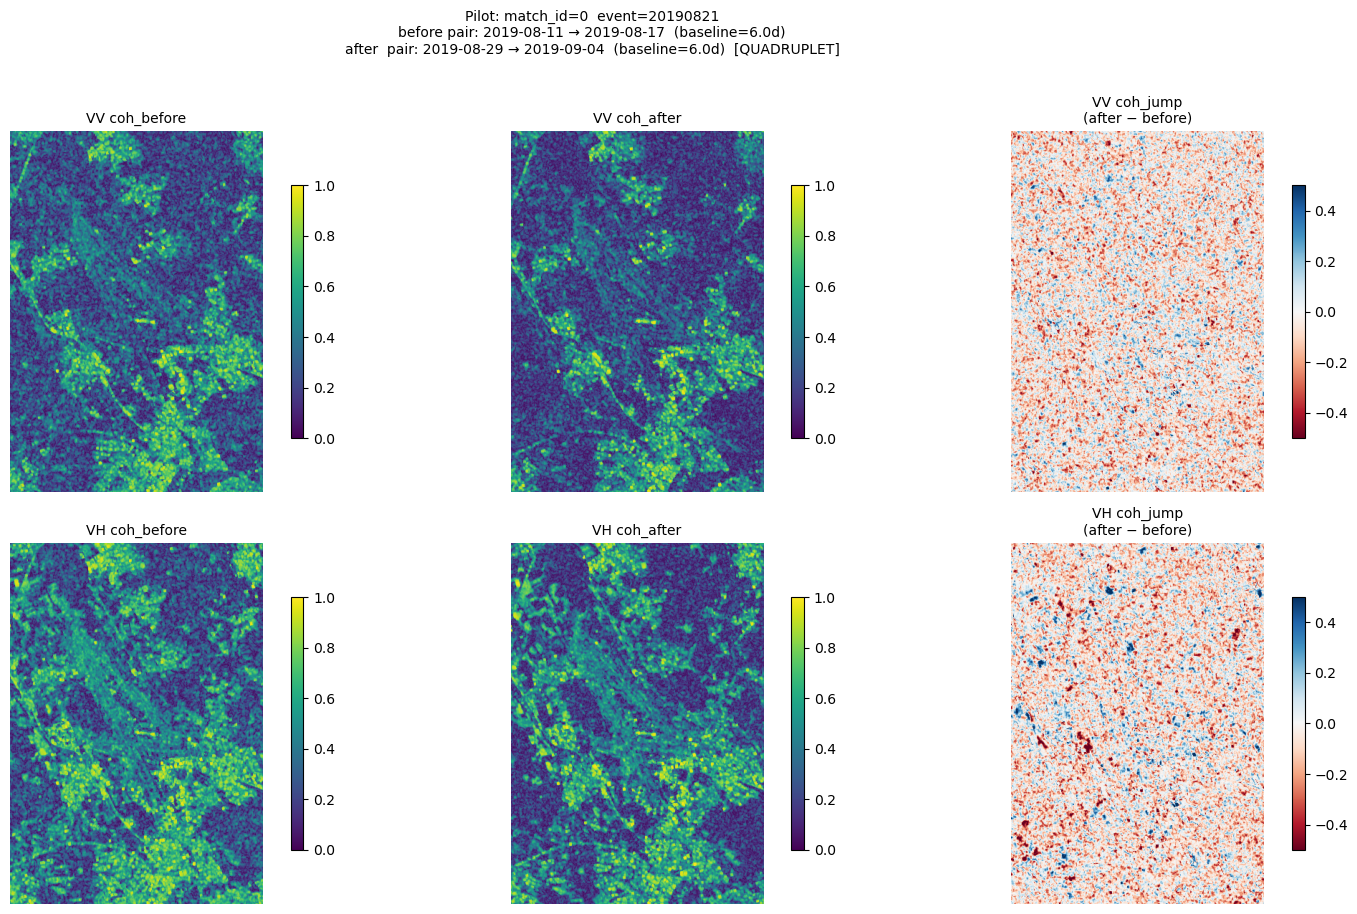

Interpretation:
  coh_jump > 0 (blue/red in RdBu)  --> coherence increased → possible mowing
  coh_jump < 0                      --> coherence decreased → growth / rain
  VV jump mean: -0.045
  VH jump mean: -0.046
  Expected: positive mean jump in a mowing season


In [94]:
# Visual comparison: coherence_before vs coherence_after

def read_coh_clipped_to_intersection(before_path, after_path):
    """
    Read VV and VH coherence from both GeoTIFFs clipped to their overlapping extent.
    Returns (coh_before_vv, coh_before_vh, coh_after_vv, coh_after_vh) as numpy arrays
    with identical shapes.
    """
    from rasterio.windows import from_bounds

    with rasterio.open(before_path) as bs, rasterio.open(after_path) as as_:
        # Intersection of spatial extents
        left   = max(bs.bounds.left,   as_.bounds.left)
        bottom = max(bs.bounds.bottom, as_.bounds.bottom)
        right  = min(bs.bounds.right,  as_.bounds.right)
        top    = min(bs.bounds.top,    as_.bounds.top)

        if left >= right or bottom >= top:
            raise ValueError('before and after coherence rasters do not overlap!')

        b_vv, b_vh = find_coh_band_indices(bs)
        a_vv, a_vh = find_coh_band_indices(as_)

        b_win = from_bounds(left, bottom, right, top, bs.transform)
        a_win = from_bounds(left, bottom, right, top, as_.transform)

        # Round window sizes to integers so shapes match exactly
        b_win = rasterio.windows.Window(
            b_win.col_off, b_win.row_off,
            round(b_win.width), round(b_win.height)
        )
        a_win = rasterio.windows.Window(
            a_win.col_off, a_win.row_off,
            round(a_win.width), round(a_win.height)
        )

        coh_b_vv = bs.read(b_vv, window=b_win).astype(float)
        coh_b_vh = bs.read(b_vh, window=b_win).astype(float) if b_vh else np.full_like(coh_b_vv, np.nan)
        coh_a_vv = as_.read(a_vv, window=a_win).astype(float)
        coh_a_vh = as_.read(a_vh, window=a_win).astype(float) if a_vh else np.full_like(coh_a_vv, np.nan)

    # If tiny 1-pixel shape mismatch remains, crop to minimum
    h = min(coh_b_vv.shape[0], coh_a_vv.shape[0])
    w = min(coh_b_vv.shape[1], coh_a_vv.shape[1])
    return (coh_b_vv[:h, :w], coh_b_vh[:h, :w],
            coh_a_vv[:h, :w], coh_a_vh[:h, :w])

# If coherence_before and coherence_after look good, read them as arrays, compute the jump, and plot.
if len(todo) > 0 and os.path.exists(before_path) and os.path.exists(after_path):
    coh_before_vv, coh_before_vh, coh_after_vv, coh_after_vh = \
        read_coh_clipped_to_intersection(before_path, after_path)

    for arr in [coh_before_vv, coh_before_vh, coh_after_vv, coh_after_vh]:
        arr[arr <= 0] = np.nan

    jump_vv = coh_after_vv - coh_before_vv
    jump_vh = coh_after_vh - coh_before_vh

    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    titles = [
        'VV coh_before', 'VV coh_after', 'VV coh_jump\n(after − before)',
        'VH coh_before', 'VH coh_after', 'VH coh_jump\n(after − before)',
    ]
    arrays = [coh_before_vv, coh_after_vv, jump_vv,
              coh_before_vh, coh_after_vh, jump_vh]
    cmaps  = ['viridis', 'viridis', 'RdBu', 'viridis', 'viridis', 'RdBu']
    vlims  = [(0, 1), (0, 1), (-0.5, 0.5),
              (0, 1), (0, 1), (-0.5, 0.5)]

    for ax, arr, title, cmap, (vmin, vmax) in zip(axes.flat, arrays, titles, cmaps, vlims):
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.7)

    pilot_row = todo.iloc[0]
    # Retrieve t4 date and quad baseline for the title
    t4_date_str = pilot_row.get('slc_t4_date', 'N/A')
    baseline_quad = pilot_row.get('baseline_after_quad', 'N/A')
    plt.suptitle(
        f"Pilot: match_id={pilot_id}  event={pilot_row['event_date_str']}\n"
        f"before pair: {pilot_row['slc_t1_date']} → {pilot_row['slc_t2_date']}  "
        f"(baseline={pilot_row['baseline_before']}d)\n"
        f"after  pair: {pilot_row['slc_t3_date']} → {t4_date_str}  "
        f"(baseline={baseline_quad}d)  [QUADRUPLET]",
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.savefig(os.path.join(COH_DIR, f'pilot_coherence_{pilot_id}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    print('Interpretation:')
    print('  coh_jump > 0 (blue/red in RdBu)  --> coherence increased → possible mowing')
    print('  coh_jump < 0                      --> coherence decreased → growth / rain')
    print(f'  VV jump mean: {np.nanmean(jump_vv):.3f}')
    print(f'  VH jump mean: {np.nanmean(jump_vh):.3f}')
    print('  Expected: positive mean jump in a mowing season')

---
## 8. Coverage Summary

In [105]:
# Count how many events have both coherence TIFFs on disk
before_done = {int(os.path.basename(f).split('_')[0])
               for f in glob.glob(os.path.join(COH_DIR, '*_coh_before.tif'))}
after_done = {int(os.path.basename(f).split('_')[0])
               for f in glob.glob(os.path.join(COH_DIR, '*_coh_after.tif'))}
fully_done = before_done & after_done

# Print summary statistics
n_valid = events['full_triplet_ok'].sum()
n_done = len(fully_done)

print('=== Coherence Processing Coverage ===')
print(f'Events with valid SLC triplet:        {n_valid}')
print(f'Events with both coherence TIFs done: {n_done}')
print(f'Remaining:                            {n_valid - n_done}')

if PILOT_MODE and n_done > 0:
    print('\nPilot succeeded. To run the full batch:')
    print('  1. Download remaining SLC batches (re-run nb07 cells 13–14)')
    print('  2. Set PILOT_MODE = False in cell 1 of this notebook')
    print('  3. Re-run cells 2 onwards')

=== Coherence Processing Coverage ===
Events with valid SLC triplet:        72
Events with both coherence TIFs done: 36
Remaining:                            36


The remaining 36 files all showed silent SNAP failures during processing (filling at least one .tif entirely with zeros) and were therefore discarded.

---

### What this notebook produces 

- `data/features_coherence/<match_id>_coh_before.tif`: coherence(t1, t2), both scenes before mowing
- `data/features_coherence/<match_id>_coh_after.tif`: coherence(t3, t4), both scenes after mowing 
- Both files: 2-band GeoTIFF, EPSG:2056, ~20 m pixel, values in [0, 1]
  - Band 1 = VV coherence
  - Band 2 = VH coherence